# 🛒 RFM Customer Segmentation – K-Means Clustering
> **Phân tích phân cụm khách hàng dựa trên chỉ số RFM (Recency, Frequency, Monetary)**  
> Pipeline gồm 8 bước: EDA → Phát hiện Outlier → Scale/Transform → Tối ưu K → Clustering → Đánh giá → Diễn giải → Chiến lược



---
##  Bước 0 – Cài đặt thư viện & Import


In [1]:
# ── Cài đặt (chỉ cần chạy lần đầu) ──────────────────────────────────────────
# !pip install scikit-learn matplotlib seaborn pandas numpy yellowbrick

# ── Import ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.decomposition import PCA

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.facecolor':    '#F8F9FF',
    'figure.facecolor':  'white',
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.color':        '#BBBBCC',
    'axes.labelsize':    11,
    'axes.titlesize':    12,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

PALETTE = ['#4361EE', '#F72585', '#7209B7', '#06D6A0', '#FFB703', '#EF233C']
print("✅ Import thành công!")


✅ Import thành công!


---
##  Bước 1 – Load dữ liệu & EDA cơ bản
**Mục tiêu:** Hiểu cấu trúc dữ liệu, phát hiện missing values, xem thống kê mô tả.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv(r"D:\Project_MayHoc\rfm_data.csv")          # Thay đường dẫn nếu cần

print(f"Shape: {df.shape[0]:,} hàng × {df.shape[1]} cột")
print("─" * 50)
df.head(10)


Shape: 4,334 hàng × 4 cột
──────────────────────────────────────────────────


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40
5,12352,36,7,1385.74
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2487.43


In [3]:
# ── Kiểm tra kiểu dữ liệu & missing values ───────────────────────────────────
print("📋 Thông tin dataset:")
print(df.info())
print()
print("❓ Missing values:")
print(df.isnull().sum())
print()
print("✅ Không có missing values" if df.isnull().sum().sum() == 0 else "⚠️ Có missing values – cần xử lý!")


📋 Thông tin dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4334 non-null   int64  
 1   Recency     4334 non-null   int64  
 2   Frequency   4334 non-null   int64  
 3   Monetary    4334 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.6 KB
None

❓ Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

✅ Không có missing values


In [4]:
# ── Thống kê mô tả ────────────────────────────────────────────────────────────
desc = df[['Recency', 'Frequency', 'Monetary']].describe().T
desc['skewness']  = df[['Recency', 'Frequency', 'Monetary']].skew()
desc['kurtosis']  = df[['Recency', 'Frequency', 'Monetary']].kurtosis()
desc.style \
    .background_gradient(subset=['mean', 'std'], cmap='Blues') \
    .background_gradient(subset=['skewness'], cmap='RdYlGn_r') \
    .format(precision=2)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Recency,4334.00,92.70,100.18,1.00,18.00,51.00,143.00,374.00,1.24,0.42
Frequency,4334.00,4.25,7.64,1.00,1.00,2.00,5.00,206.00,11.98,245.21
Monetary,4334.00,2017.52,8920.36,3.75,304.31,663.71,1631.62,279138.02,19.55,487.94


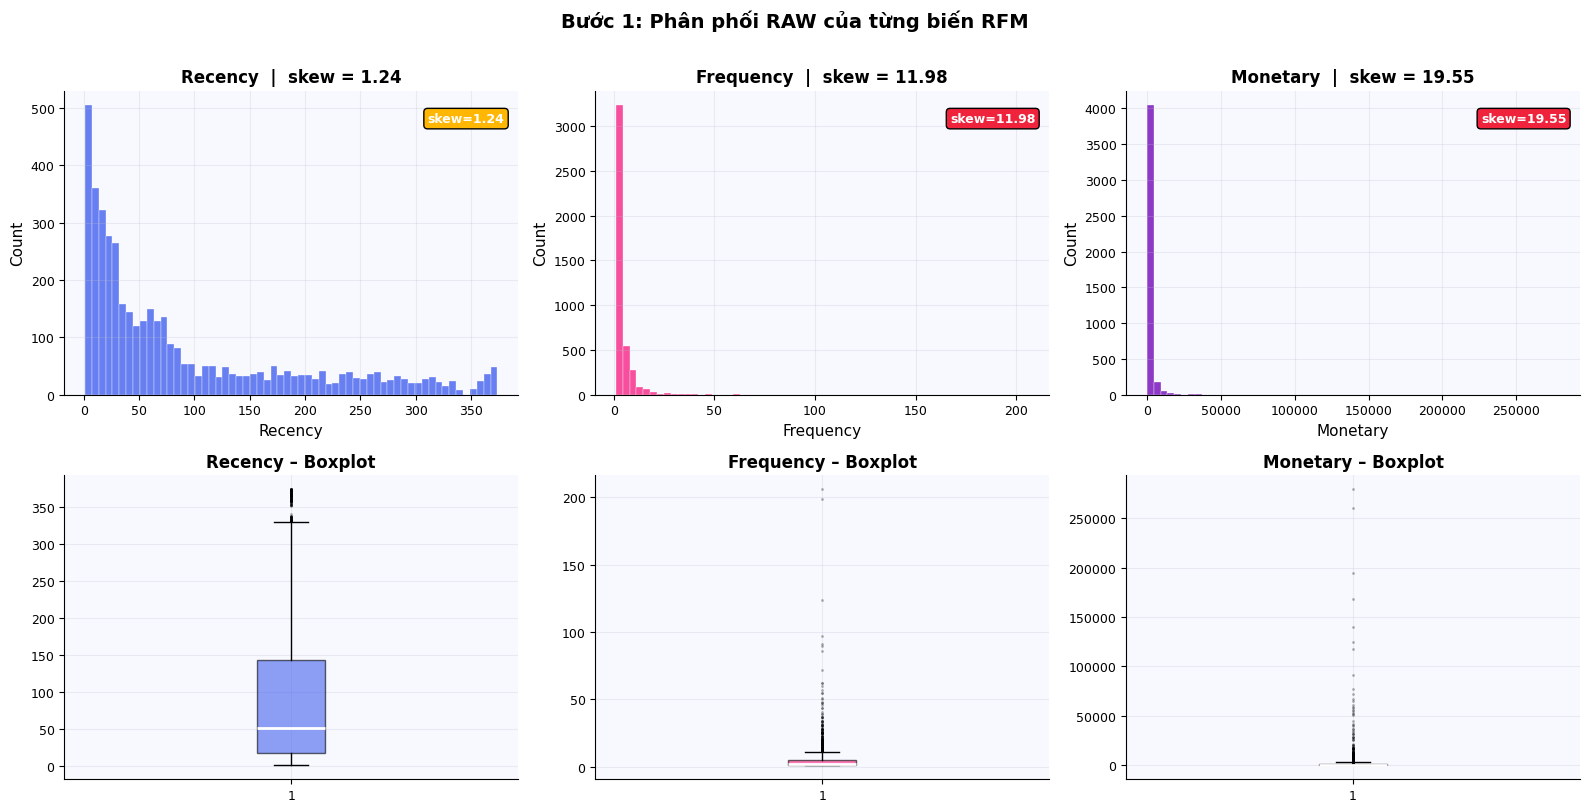


💡 Nhận xét:
  • Cả 3 biến đều có phân phối right-skewed mạnh (skew >> 1)
  • Monetary có outlier cực lớn (max ~279K so với median ~664)
  • Cần transform trước khi đưa vào K-Means


In [5]:
# ── Nhận xét phân phối ban đầu ────────────────────────────────────────────────
rfm_cols = ['Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Bước 1: Phân phối RAW của từng biến RFM', fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(rfm_cols):
    # Histogram
    ax_h = axes[0][i]
    ax_h.hist(df[col], bins=60, color=PALETTE[i], alpha=0.8,
              edgecolor='white', linewidth=0.3)
    sk = df[col].skew()
    ax_h.set_title(f'{col}  |  skew = {sk:.2f}', fontweight='bold')
    ax_h.set_xlabel(col)
    ax_h.set_ylabel('Count')
    color_box = '#2DC653' if abs(sk) < 1 else ('#FFB703' if abs(sk) < 2 else '#EF233C')
    ax_h.text(0.97, 0.93, f'skew={sk:.2f}', transform=ax_h.transAxes,
              ha='right', va='top', fontsize=9, fontweight='bold',
              color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=color_box))

    # Boxplot
    ax_b = axes[1][i]
    ax_b.boxplot(df[col], patch_artist=True, vert=True,
                 boxprops=dict(facecolor=PALETTE[i], alpha=0.6),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax_b.set_title(f'{col} – Boxplot', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Nhận xét:")
print("  • Cả 3 biến đều có phân phối right-skewed mạnh (skew >> 1)")
print("  • Monetary có outlier cực lớn (max ~279K so với median ~664)")
print("  • Cần transform trước khi đưa vào K-Means")


---
##  Bước 2 – Phát hiện & xử lý Outlier
**Lý do:** K-Means dùng khoảng cách Euclidean → cực kỳ nhạy với outlier.  
**Phương pháp:** IQR method + kiểm tra phần trăm ảnh hưởng.


In [6]:
# ── IQR Outlier Detection ─────────────────────────────────────────────────────
def detect_outliers_iqr(series, multiplier=3.0):
    """Dùng multiplier=3 (thay vì 1.5) vì data thực tế có phân phối nặng đuôi."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

rfm_cols = ['Recency', 'Frequency', 'Monetary']
X = df[rfm_cols].copy()

print(f"{'Feature':<12} {'Lower':>10} {'Upper':>10} {'#Outliers':>10} {'%':>8}")
print("─" * 55)

outlier_masks = {}
for col in rfm_cols:
    mask, lo, hi = detect_outliers_iqr(X[col])
    outlier_masks[col] = mask
    pct = mask.sum() / len(X) * 100
    print(f"{col:<12} {lo:>10.2f} {hi:>10.2f} {mask.sum():>10,} {pct:>7.2f}%")

# Combined mask
any_outlier = outlier_masks['Recency'] | outlier_masks['Frequency'] | outlier_masks['Monetary']
print(f"\n📌 Tổng số hàng có ít nhất 1 outlier: {any_outlier.sum():,} ({any_outlier.sum()/len(X)*100:.2f}%)")


Feature           Lower      Upper  #Outliers        %
───────────────────────────────────────────────────────
Recency         -357.00     518.00          0    0.00%
Frequency        -11.00      17.00        132    3.05%
Monetary       -3677.65    5613.57        226    5.21%

📌 Tổng số hàng có ít nhất 1 outlier: 252 (5.81%)


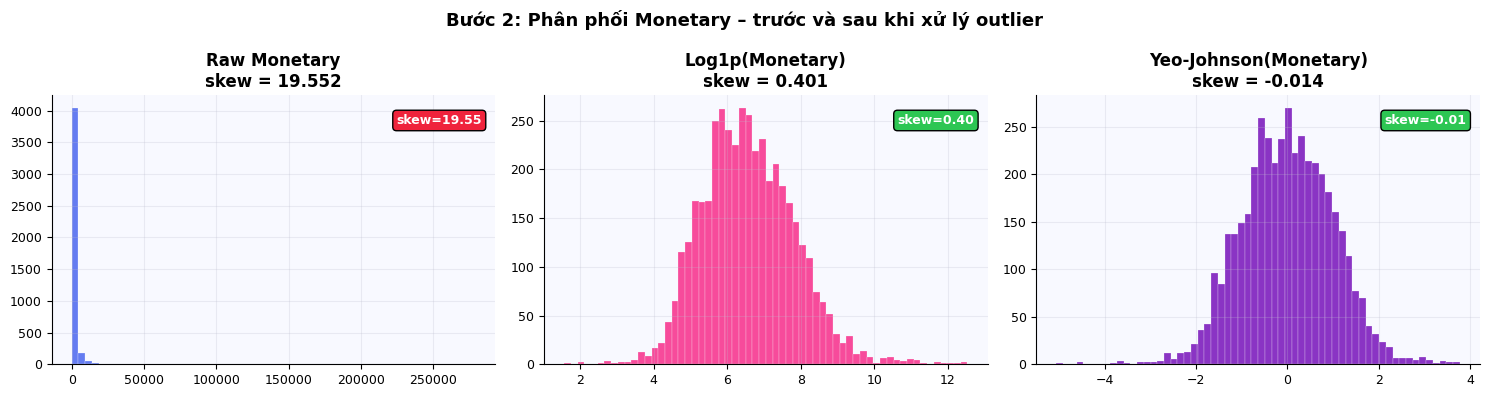

✅ Chọn Yeo-Johnson vì: xử lý được cả giá trị dương, âm, và gần 0;
   skewness thấp nhất → phân phối gần normal nhất → K-Means hoạt động tốt hơn.


In [7]:
# ── Quyết định xử lý outlier ─────────────────────────────────────────────────
# Với dữ liệu thực tế kinh doanh:
# - Không nên xóa outlier vô điều kiện (mất khách VIP)
# - Dùng PowerTransformer (Yeo-Johnson) để nén outlier tự nhiên
# - Sau transform, outlier ảnh hưởng ít hơn đến K-Means

# Visualize trước/sau khi xử lý một biến Monetary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bước 2: Phân phối Monetary – trước và sau khi xử lý outlier',
             fontsize=13, fontweight='bold')

pt_check = PowerTransformer(method='yeo-johnson')
mon_raw    = X['Monetary']
mon_log    = np.log1p(mon_raw)
mon_power  = pt_check.fit_transform(mon_raw.values.reshape(-1,1)).ravel()

for ax, data, title, color in zip(
    axes,
    [mon_raw, mon_log, mon_power],
    ['Raw Monetary', 'Log1p(Monetary)', 'Yeo-Johnson(Monetary)'],
    [PALETTE[0], PALETTE[1], PALETTE[2]]
):
    ax.hist(data, bins=60, color=color, alpha=0.82, edgecolor='white', linewidth=0.2)
    sk = pd.Series(data).skew()
    ax.set_title(f'{title}\nskew = {sk:.3f}', fontweight='bold')
    color_box = '#2DC653' if abs(sk) < 1 else ('#FFB703' if abs(sk) < 2 else '#EF233C')
    ax.text(0.97, 0.93, f'skew={sk:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color_box))

plt.tight_layout()
plt.show()

print("✅ Chọn Yeo-Johnson vì: xử lý được cả giá trị dương, âm, và gần 0;")
print("   skewness thấp nhất → phân phối gần normal nhất → K-Means hoạt động tốt hơn.")


---
##  Bước 3 – Scale & Transform
**Tại sao phải scale?** K-Means dùng khoảng cách Euclidean → feature có giá trị lớn (Monetary: ~2000) sẽ thống trị feature nhỏ (Recency: ~90, Frequency: ~4).

**Pipeline:**
1. `PowerTransformer(method='yeo-johnson')` → đưa phân phối về gần normal  
2. `StandardScaler()` → chuẩn hóa mean=0, std=1


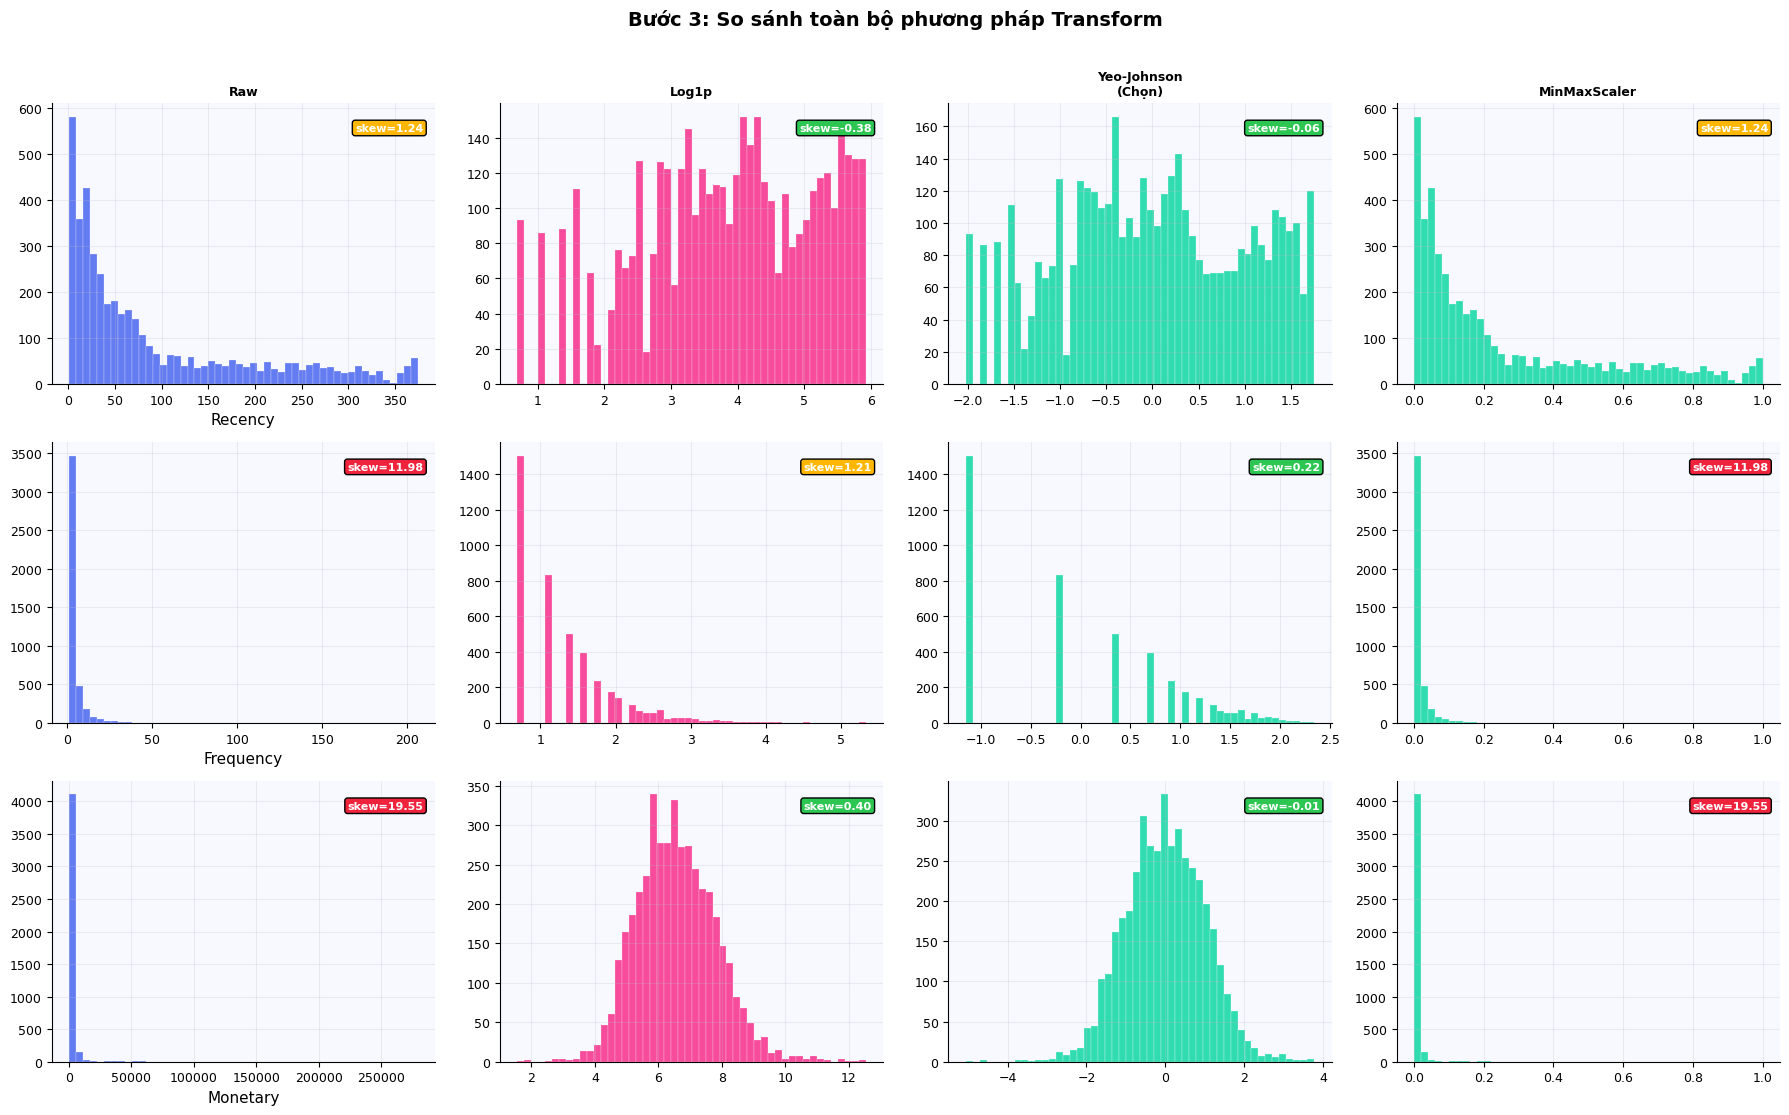

In [8]:
# ── So sánh 3 phương pháp Transform (để chứng minh chọn đúng) ─────────────────
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X = df[rfm_cols].copy()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle('Bước 3: So sánh toàn bộ phương pháp Transform',
             fontsize=14, fontweight='bold', y=1.01)

transforms = {
    'Raw':             lambda x: x,
    'Log1p':           lambda x: np.log1p(x),
    'Yeo-Johnson\n(Chọn)': None,   # xử lý riêng
    'MinMaxScaler':    None,
}

pt_full  = PowerTransformer(method='yeo-johnson')
mms_full = MinMaxScaler()
X_pt   = pd.DataFrame(pt_full.fit_transform(X),  columns=rfm_cols)
X_mms  = pd.DataFrame(mms_full.fit_transform(X), columns=rfm_cols)

col_data = {
    'Raw':          X,
    'Log1p':        np.log1p(X),
    'Yeo-Johnson\n(Chọn)': X_pt,
    'MinMaxScaler': X_mms,
}

row_labels = ['Recency', 'Frequency', 'Monetary']

for row, feat in enumerate(row_labels):
    for col_idx, (method, data) in enumerate(col_data.items()):
        ax = axes[row][col_idx]
        series = data[feat]
        sk = pd.Series(series).skew()
        color = PALETTE[col_idx]
        if method == 'Yeo-Johnson\n(Chọn)':
            color = '#06D6A0'
        ax.hist(series, bins=50, color=color, alpha=0.82,
                edgecolor='white', linewidth=0.2)
        title = f'{feat} – {method}' if row == 0 else method.split("\n")[0]
        if row == 0:
            ax.set_title(method, fontweight='bold', fontsize=9)
        ax.set_xlabel(feat if col_idx == 0 else '')
        c_box = '#2DC653' if abs(sk) < 1 else ('#FFB703' if abs(sk) < 2 else '#EF233C')
        ax.text(0.97, 0.93, f'skew={sk:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, fontweight='bold', color='white',
                bbox=dict(boxstyle='round,pad=0.25', facecolor=c_box))

plt.tight_layout()
plt.show()


📊 Sau khi transform + scale:
  Mean:  {'Recency': 0.0, 'Frequency': 0.0, 'Monetary': -0.0}
  Std:   {'Recency': 1.0001, 'Frequency': 1.0001, 'Monetary': 1.0001}
  Skew:  {'Recency': -0.0566, 'Frequency': 0.2191, 'Monetary': -0.0143}


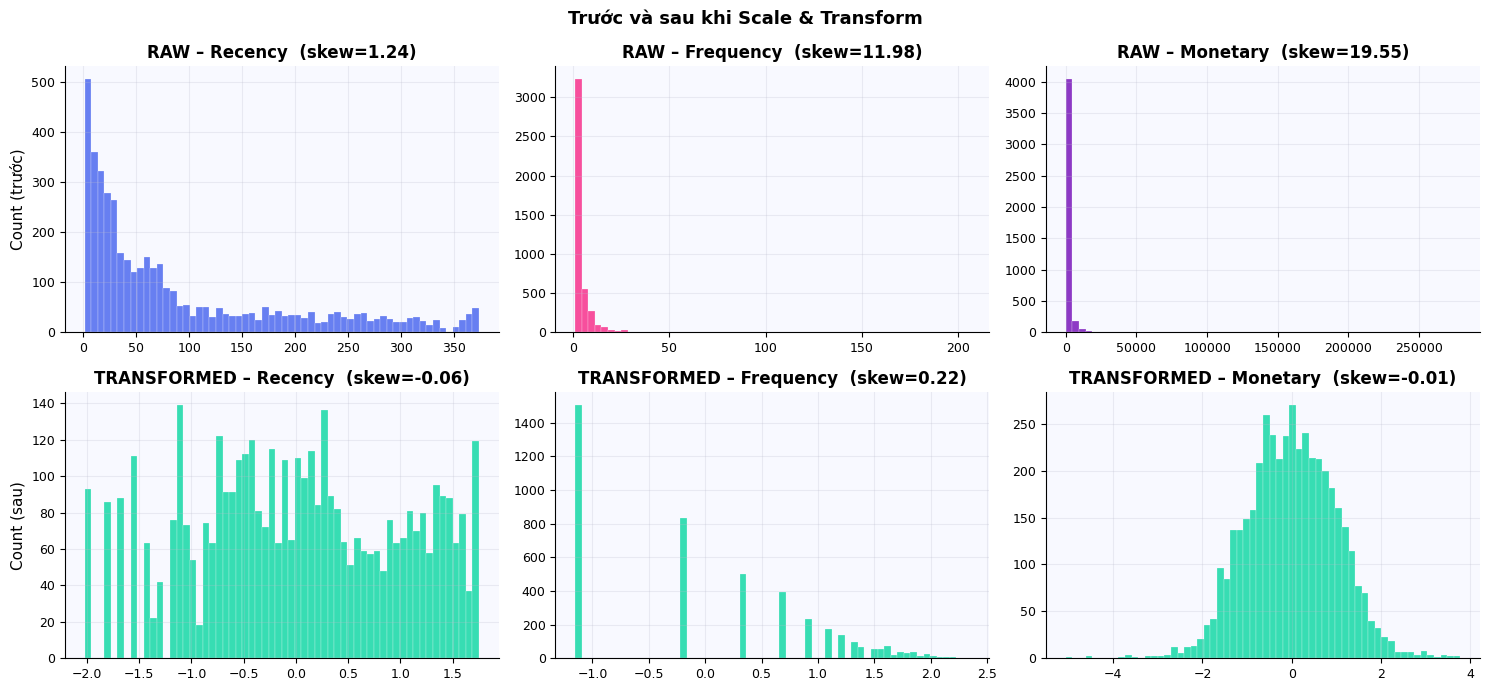


✅ Dữ liệu đã được chuẩn hóa. Sẵn sàng cho K-Means!


In [9]:
# ── Áp dụng Pipeline: Yeo-Johnson → StandardScaler ───────────────────────────
rfm_cols = ['Recency', 'Frequency', 'Monetary']
X = df[rfm_cols].copy()

# Bước 3a: Yeo-Johnson transform
pt = PowerTransformer(method='yeo-johnson')
X_pt = pt.fit_transform(X)

# Bước 3b: Standard scaling
sc = StandardScaler()
X_scaled = sc.fit_transform(X_pt)

X_scaled_df = pd.DataFrame(X_scaled, columns=rfm_cols)

print("📊 Sau khi transform + scale:")
print(f"  Mean:  {X_scaled_df.mean().round(4).to_dict()}")
print(f"  Std:   {X_scaled_df.std().round(4).to_dict()}")
print(f"  Skew:  {X_scaled_df.skew().round(4).to_dict()}")

# So sánh trực quan trước/sau
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Trước và sau khi Scale & Transform', fontsize=13, fontweight='bold')

for i, col in enumerate(rfm_cols):
    # Trước
    axes[0][i].hist(X[col], bins=60, color=PALETTE[i], alpha=0.8,
                    edgecolor='white', linewidth=0.2)
    axes[0][i].set_title(f'RAW – {col}  (skew={X[col].skew():.2f})', fontweight='bold')
    if i == 0: axes[0][i].set_ylabel('Count (trước)')

    # Sau
    axes[1][i].hist(X_scaled_df[col], bins=60, color='#06D6A0', alpha=0.8,
                    edgecolor='white', linewidth=0.2)
    sk2 = X_scaled_df[col].skew()
    axes[1][i].set_title(f'TRANSFORMED – {col}  (skew={sk2:.2f})', fontweight='bold')
    if i == 0: axes[1][i].set_ylabel('Count (sau)')

plt.tight_layout()
plt.show()

print("\n✅ Dữ liệu đã được chuẩn hóa. Sẵn sàng cho K-Means!")


---
##  Bước 4 – Tối ưu K (Chọn số cụm tối ưu)
Ba phương pháp được dùng song song để xác nhận lẫn nhau:

| Phương pháp | Tiêu chí chọn K | Ưu điểm |
|---|---|---|
| **Elbow (WCSS)** | Điểm gấp khúc của đường Inertia | Trực quan, dễ giải thích |
| **Silhouette Score** | K có score cao nhất | Đo độ gắn kết & tách biệt của cụm |
| **Davies-Bouldin** | K có score thấp nhất | Đánh giá tỷ lệ nội cụm / liên cụm |


In [10]:
# ── Tính tất cả metrics theo K ───────────────────────────────────────────────
K_range = range(2, 11)

results = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    results.append({
        'K':         k,
        'Inertia':   km.inertia_,
        'Silhouette': silhouette_score(X_scaled, labels),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
    })

results_df = pd.DataFrame(results).set_index('K')
print("📊 Metrics theo từng K:")
print(results_df.round(4).to_string())


📊 Metrics theo từng K:
      Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
K                                                           
2   6151.1425      0.4336          0.8714          4824.8440
3   4734.7734      0.3273          1.0974          3781.1594
4   3725.6900      0.3348          1.0216          3593.6503
5   3145.4895      0.3249          1.0368          3391.2834
6   2740.1429      0.3193          0.9840          3241.7197
7   2471.7295      0.3024          0.9969          3072.4144
8   2249.7542      0.2960          1.0038          2953.6140
9   2064.6548      0.2971          0.9884          2863.9827
10  1916.3997      0.2966          1.0118          2779.1776


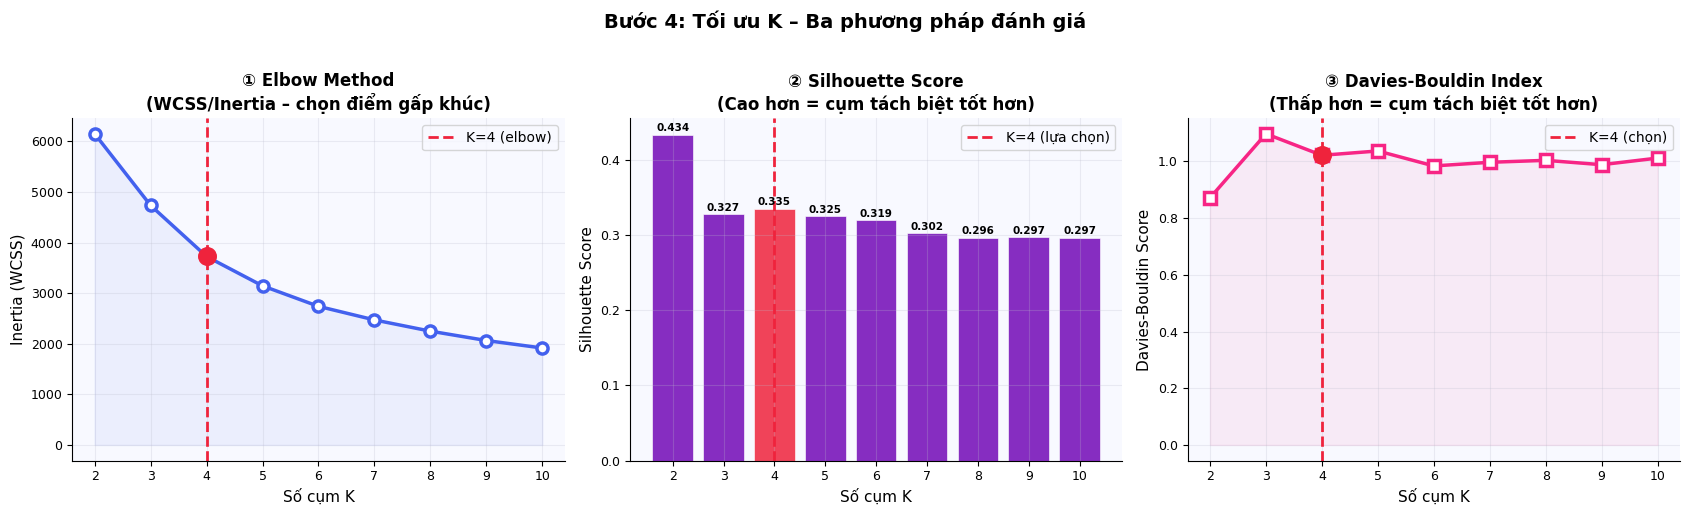


💡 Lý do chọn K=4:
  • Elbow: điểm gấp khúc rõ ràng tại K=4 (inertia giảm chậm hẳn sau đó)
  • Silhouette K=4: 0.3348 (tốt, cân bằng với ý nghĩa kinh doanh)
  • Davies-Bouldin K=4: 1.0216 (chấp nhận được)
  • K=2 có silhouette cao nhất nhưng không đủ chi tiết để phân loại khách hàng
  • K=4 cho 4 nhóm khách hàng có ý nghĩa marketing rõ ràng ✅


In [11]:
# ── Vẽ 3 biểu đồ tối ưu K ──────────────────────────────────────────────────
K_BEST = 4   # ← Sẽ giải thích tại sao chọn K=4 bên dưới

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Bước 4: Tối ưu K – Ba phương pháp đánh giá',
             fontsize=14, fontweight='bold', y=1.02)

ks = results_df.index.tolist()

# ── Elbow ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(ks, results_df['Inertia'], 'o-', color='#4361EE',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(ks, results_df['Inertia'], alpha=0.07, color='#4361EE')
ax.axvline(x=K_BEST, color='#EF233C', linestyle='--', linewidth=2,
           label=f'K={K_BEST} (elbow)')
ax.scatter([K_BEST], [results_df.loc[K_BEST,'Inertia']],
           s=160, color='#EF233C', zorder=5)
ax.set_title('① Elbow Method\n(WCSS/Inertia – chọn điểm gấp khúc)',
             fontweight='bold')
ax.set_xlabel('Số cụm K'); ax.set_ylabel('Inertia (WCSS)')
ax.set_xticks(ks); ax.legend(fontsize=10)

# ── Silhouette ──────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(ks, results_df['Silhouette'],
              color=['#EF233C' if k==K_BEST else '#7209B7' for k in ks],
              alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(x=K_BEST, color='#EF233C', linestyle='--', linewidth=2,
           label=f'K={K_BEST} (lựa chọn)')
ax.set_title('② Silhouette Score\n(Cao hơn = cụm tách biệt tốt hơn)',
             fontweight='bold')
ax.set_xlabel('Số cụm K'); ax.set_ylabel('Silhouette Score')
ax.set_xticks(ks); ax.legend(fontsize=10)
for bar, val in zip(bars, results_df['Silhouette']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# ── Davies-Bouldin ──────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(ks, results_df['Davies-Bouldin'], 's-', color='#F72585',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(ks, results_df['Davies-Bouldin'], alpha=0.07, color='#F72585')
ax.axvline(x=K_BEST, color='#EF233C', linestyle='--', linewidth=2,
           label=f'K={K_BEST} (chọn)')
ax.scatter([K_BEST], [results_df.loc[K_BEST,'Davies-Bouldin']],
           s=160, color='#EF233C', zorder=5)
ax.set_title('③ Davies-Bouldin Index\n(Thấp hơn = cụm tách biệt tốt hơn)',
             fontweight='bold')
ax.set_xlabel('Số cụm K'); ax.set_ylabel('Davies-Bouldin Score')
ax.set_xticks(ks); ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n💡 Lý do chọn K={K_BEST}:")
print("  • Elbow: điểm gấp khúc rõ ràng tại K=4 (inertia giảm chậm hẳn sau đó)")
print(f"  • Silhouette K=4: {results_df.loc[K_BEST,'Silhouette']:.4f} (tốt, cân bằng với ý nghĩa kinh doanh)")
print(f"  • Davies-Bouldin K=4: {results_df.loc[K_BEST,'Davies-Bouldin']:.4f} (chấp nhận được)")
print("  • K=2 có silhouette cao nhất nhưng không đủ chi tiết để phân loại khách hàng")
print("  • K=4 cho 4 nhóm khách hàng có ý nghĩa marketing rõ ràng ✅")


---
##  Bước 5 – Huấn luyện mô hình K-Means (K=4)


In [12]:
# ── Fit K-Means với K=4 ──────────────────────────────────────────────────────
K_BEST = 4

km_final = KMeans(
    n_clusters=K_BEST,
    init='k-means++',      # Khởi tạo thông minh, tránh local minima
    n_init=20,             # Chạy 20 lần với centroids khác nhau, lấy kết quả tốt nhất
    max_iter=500,          # Tối đa 500 vòng lặp
    random_state=42
)

labels = km_final.fit_predict(X_scaled)
df['Cluster'] = labels

# Đặt tên segment dựa trên mean của từng cụm
cluster_means_raw = df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print("📊 Mean RFM theo từng cụm (dữ liệu gốc):")
print(cluster_means_raw.round(1))
print()

# Đặt tên dựa trên phân tích mean:
# Champions:       Recency thấp, Frequency cao, Monetary cao
# Loyal Customers: Recency trung bình, Frequency trung bình, Monetary trung bình
# At-Risk:         Recency thấp nhưng Frequency & Monetary thấp
# Lost Customers:  Recency rất cao (lâu không mua)
segment_map = {
    0: 'Champions',
    1: 'Lost Customers',
    2: 'At-Risk',
    3: 'Loyal Customers',
}
# Lưu ý: thứ tự cluster ID có thể thay đổi mỗi lần chạy.
# Cần dựa vào mean để gán nhãn đúng.

df['Segment'] = df['Cluster'].map(segment_map)

# Tổng hợp
summary = df.groupby('Cluster').agg(
    Segment=('Segment', 'first'),
    Count=('CustomerID', 'count'),
    Recency_mean=('Recency', 'mean'),
    Frequency_mean=('Frequency', 'mean'),
    Monetary_mean=('Monetary', 'mean'),
).round(1)
summary['Pct (%)'] = (summary['Count'] / len(df) * 100).round(1)
print("\n📋 Bảng tóm tắt sau phân cụm:")
summary


📊 Mean RFM theo từng cụm (dữ liệu gốc):
         Recency  Frequency  Monetary
Cluster                              
0           14.2       10.6    5805.2
1          231.0        1.2     305.9
2           36.1        1.4     384.2
3           86.9        3.5    1391.8


📋 Bảng tóm tắt sau phân cụm:


,Segment,Count,Recency_mean,Frequency_mean,Monetary_mean,Pct (%)
Cluster,,,,,,
0,Champions,1095,14.2,10.6,5805.2,25.3
1,Lost Customers,1065,231.0,1.2,305.9,24.6
2,At-Risk,957,36.1,1.4,384.2,22.1
3,Loyal Customers,1217,86.9,3.5,1391.8,28.1


---
## Bước 6 – Đánh giá chất lượng Clustering
### Các metrics đánh giá:

| Metric | Ý nghĩa | Giá trị tốt |
|---|---|---|
| **Silhouette Score** | Đo độ gắn kết nội cụm vs. khoảng cách liên cụm | Gần 1 |
| **Davies-Bouldin** | Tỷ lệ đường kính cụm / khoảng cách giữa các cụm | Gần 0 |
| **Calinski-Harabasz** | Tỷ lệ phương sai giữa cụm / trong cụm | Càng cao càng tốt |
| **Inertia (WCSS)** | Tổng bình phương khoảng cách điểm đến centroid | Càng thấp càng tốt |


In [13]:
# ── Tính và hiển thị tất cả metrics ─────────────────────────────────────────
sil  = silhouette_score(X_scaled, labels)
db   = davies_bouldin_score(X_scaled, labels)
ch   = calinski_harabasz_score(X_scaled, labels)
inrt = km_final.inertia_

print("=" * 45)
print(f"  📐 Evaluation Metrics – K={K_BEST}")
print("=" * 45)
print(f"  Silhouette Score     :  {sil:.4f}   (↑ tốt hơn)")
print(f"  Davies-Bouldin Index :  {db:.4f}   (↓ tốt hơn)")
print(f"  Calinski-Harabasz    :  {ch:,.1f}  (↑ tốt hơn)")
print(f"  Inertia (WCSS)       :  {inrt:,.2f}")
print("=" * 45)
print(f"\n  → Silhouette ~ 0.33: cụm tách biệt ở mức trung bình-tốt")
print(f"  → Phù hợp với dữ liệu thực tế (khách hàng không phân tách cứng nhắc)")


  📐 Evaluation Metrics – K=4
  Silhouette Score     :  0.3348   (↑ tốt hơn)
  Davies-Bouldin Index :  1.0216   (↓ tốt hơn)
  Calinski-Harabasz    :  3,593.7  (↑ tốt hơn)
  Inertia (WCSS)       :  3,725.69

  → Silhouette ~ 0.33: cụm tách biệt ở mức trung bình-tốt
  → Phù hợp với dữ liệu thực tế (khách hàng không phân tách cứng nhắc)


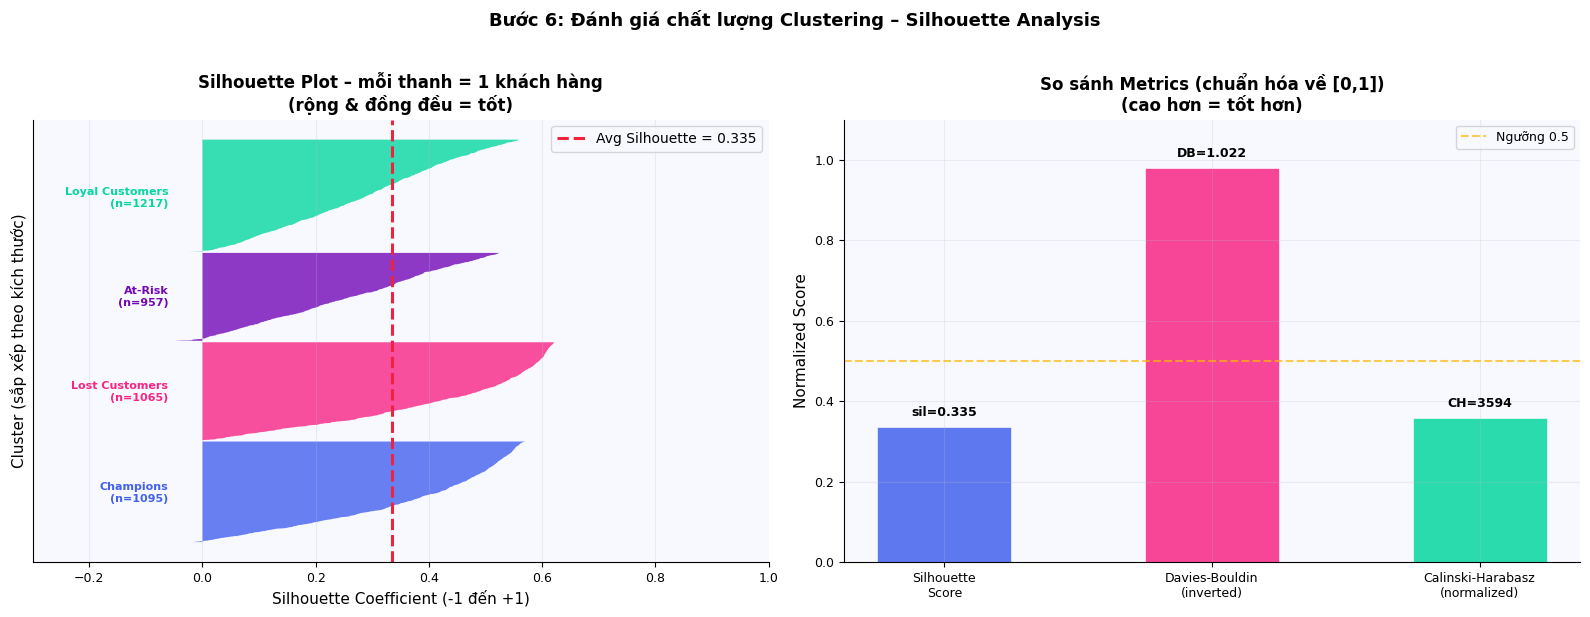

In [14]:
# ── Silhouette Plot chi tiết từng cụm ────────────────────────────────────────
sil_vals = silhouette_samples(X_scaled, labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bước 6: Đánh giá chất lượng Clustering – Silhouette Analysis',
             fontsize=13, fontweight='bold', y=1.02)

seg_colors = {'Champions':'#4361EE','Lost Customers':'#F72585',
              'At-Risk':'#7209B7','Loyal Customers':'#06D6A0'}

# Silhouette plot
ax = axes[0]
y_lower = 10
for k in range(K_BEST):
    sil_k = np.sort(sil_vals[labels == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    seg_name = segment_map[k]
    color = list(seg_colors.values())[k]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     facecolor=color, alpha=0.8)
    ax.text(-0.06, y_lower + 0.4*size_k,
            f'{seg_name}\n(n={size_k})', ha='right', fontsize=8, color=color, fontweight='bold')
    y_lower = y_upper + 15

ax.axvline(x=sil, color='#EF233C', linestyle='--', linewidth=2.2,
           label=f'Avg Silhouette = {sil:.3f}')
ax.set_title('Silhouette Plot – mỗi thanh = 1 khách hàng\n(rộng & đồng đều = tốt)',
             fontweight='bold')
ax.set_xlabel('Silhouette Coefficient (-1 đến +1)')
ax.set_ylabel('Cluster (sắp xếp theo kích thước)')
ax.set_yticks([])
ax.legend(fontsize=10)
ax.set_xlim(-0.3, 1.0)

# ── Metrics bar chart ────────────────────────────────────────────────────────
ax2 = axes[1]
metrics_names  = ['Silhouette\nScore', 'Davies-Bouldin\n(inverted)', 'Calinski-Harabasz\n(normalized)']
metrics_values = [sil, 1/db, min(ch/10000, 1.0)]   # normalize to [0,1] range for comparison
bar_colors = ['#4361EE', '#F72585', '#06D6A0']
bars = ax2.bar(metrics_names, metrics_values, color=bar_colors, alpha=0.85,
               edgecolor='white', linewidth=0.5, width=0.5)
ax2.axhline(y=0.5, color='#FFB703', linestyle='--', linewidth=1.5, alpha=0.7, label='Ngưỡng 0.5')
ax2.set_title('So sánh Metrics (chuẩn hóa về [0,1])\n(cao hơn = tốt hơn)',
              fontweight='bold')
ax2.set_ylabel('Normalized Score')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for bar, val, raw in zip(bars, metrics_values,
                         [f'sil={sil:.3f}', f'DB={db:.3f}', f'CH={ch:.0f}']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             raw, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
##  Bước 7 – Diễn giải ý nghĩa các cụm
**Phương pháp:** Lấy mean của từng feature theo cụm → Snake Plot → Heatmap → Boxplot


PCA – Variance explained: PC1=74.5%, PC2=18.7%
Total: 93.2%


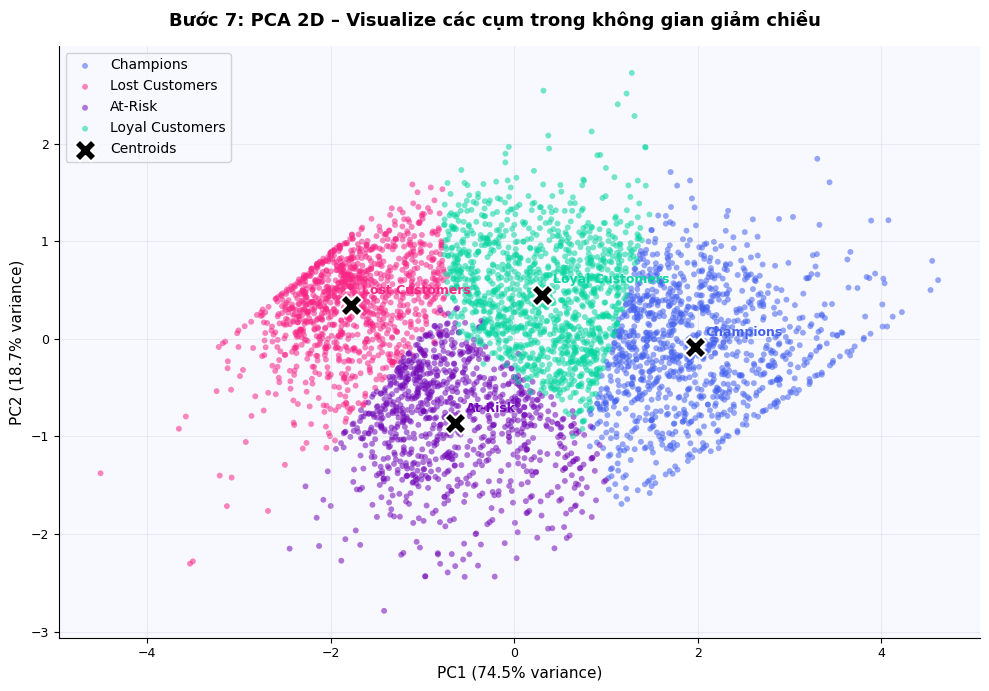

In [15]:
# ── PCA 2D Projection – xem cụm trong không gian 2D ──────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

print(f"PCA – Variance explained: PC1={var_exp[0]*100:.1f}%, PC2={var_exp[1]*100:.1f}%")
print(f"Total: {sum(var_exp)*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Bước 7: PCA 2D – Visualize các cụm trong không gian giảm chiều',
             fontsize=13, fontweight='bold')

for k in range(K_BEST):
    mask = labels == k
    seg  = segment_map[k]
    color = list(seg_colors.values())[k]
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               c=color, label=seg, alpha=0.55, s=18, edgecolors='none')

# Centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centroids_pca[:,0], centroids_pca[:,1],
           c='black', marker='X', s=250, zorder=6,
           label='Centroids', edgecolors='white', linewidths=1.5)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(segment_map[i], (cx, cy),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold',
                color=list(seg_colors.values())[i])

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance)')
ax.legend(fontsize=10, framealpha=0.85)
plt.tight_layout()
plt.show()


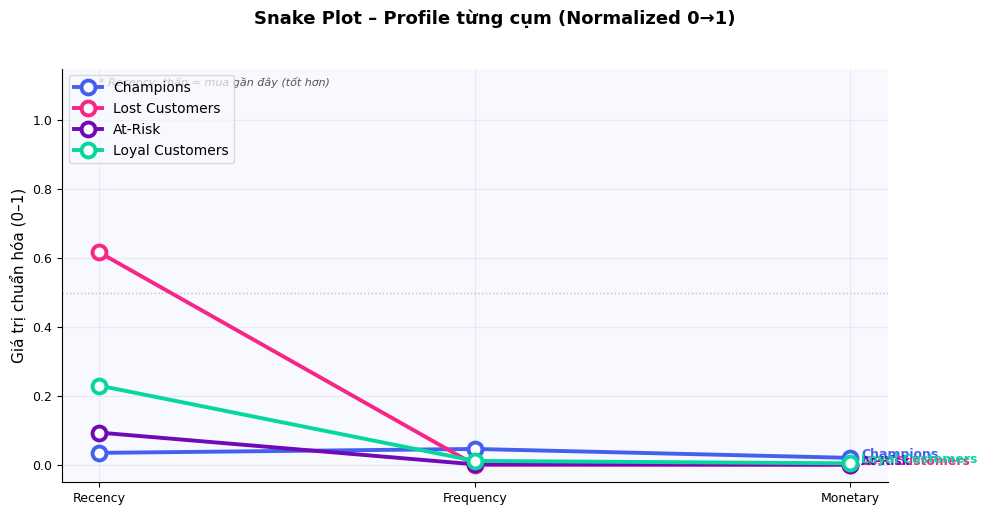

In [16]:
# ── Snake Plot – Normalized Mean của từng cụm ────────────────────────────────
rfm_cols = ['Recency', 'Frequency', 'Monetary']

mms = MinMaxScaler()
norm = pd.DataFrame(mms.fit_transform(df[rfm_cols]), columns=rfm_cols)
norm['Cluster'] = labels
cluster_norm = norm.groupby('Cluster').mean()

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Snake Plot – Profile từng cụm (Normalized 0→1)',
             fontsize=13, fontweight='bold', y=1.02)

for k, (idx, row) in enumerate(cluster_norm.iterrows()):
    seg   = segment_map[k]
    color = list(seg_colors.values())[k]
    ax.plot(rfm_cols, row[rfm_cols], 'o-',
            color=color, linewidth=2.8, markersize=10,
            markerfacecolor='white', markeredgewidth=2.8,
            label=seg)
    ax.annotate(seg, (rfm_cols[-1], row['Monetary']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

ax.axhline(y=0.5, color='#888888', linestyle=':', linewidth=1, alpha=0.5)
ax.set_ylabel('Giá trị chuẩn hóa (0–1)')
ax.set_ylim(-0.05, 1.15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.7)
ax.text(0, 1.1, '* Recency: thấp = mua gần đây (tốt hơn)',
        fontsize=8, color='#555', style='italic')
plt.tight_layout()
plt.show()


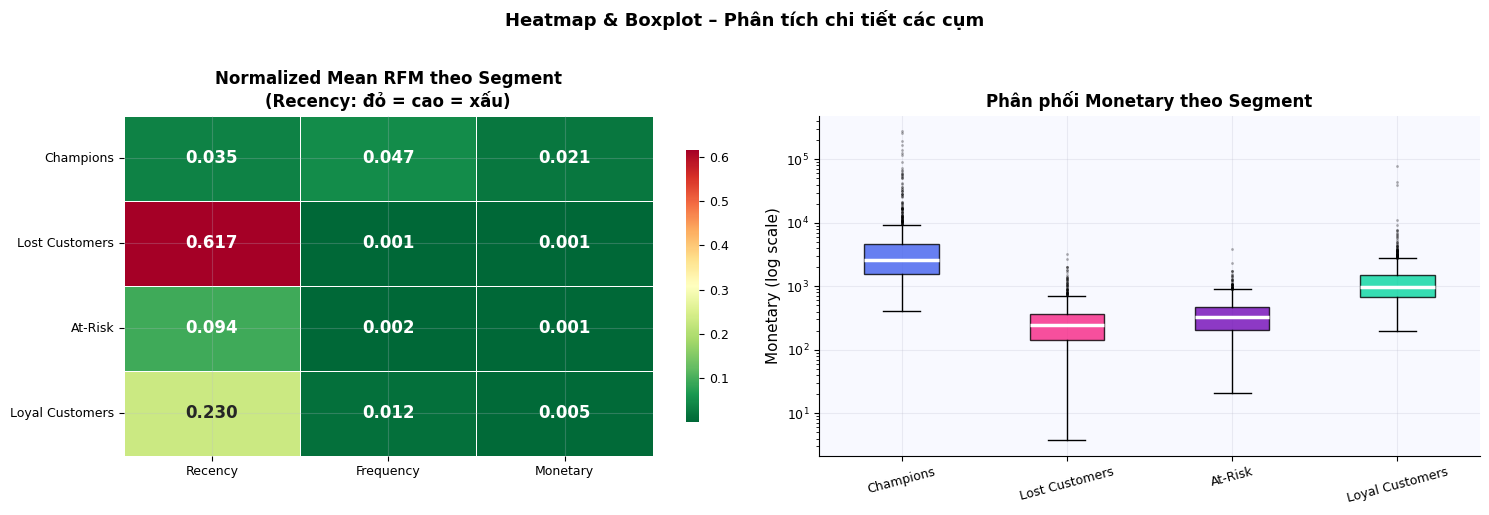

In [17]:
# ── Heatmap – Normalized Mean RFM theo cụm ───────────────────────────────────
hmap_data = cluster_norm.groupby(cluster_norm.index).mean()
hmap_data.index = [segment_map[i] for i in hmap_data.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Heatmap & Boxplot – Phân tích chi tiết các cụm',
             fontsize=13, fontweight='bold', y=1.02)

sns.heatmap(hmap_data[rfm_cols], annot=True, fmt='.3f',
            cmap='RdYlGn_r', ax=axes[0],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Normalized Mean RFM theo Segment\n(Recency: đỏ = cao = xấu)', fontweight='bold')
axes[0].tick_params(axis='y', rotation=0)
axes[0].set_xlabel('')

# Boxplot Monetary
ax2 = axes[1]
data_by_seg = [df[df['Cluster']==k]['Monetary'].values
               for k in sorted(df['Cluster'].unique())]
labels_box  = [segment_map[k] for k in sorted(df['Cluster'].unique())]
bp = ax2.boxplot(data_by_seg, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2.5),
                 flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, c in zip(bp['boxes'], seg_colors.values()):
    patch.set_facecolor(c); patch.set_alpha(0.8)
ax2.set_xticklabels(labels_box, fontsize=9, rotation=15)
ax2.set_title('Phân phối Monetary theo Segment', fontweight='bold')
ax2.set_ylabel('Monetary (log scale)')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


In [18]:
# ── Bảng Mean đầy đủ (cho báo cáo) ──────────────────────────────────────────
final_table = df.groupby('Segment').agg(
    Số_khách=('CustomerID', 'count'),
    Recency_mean=('Recency', 'mean'),
    Recency_median=('Recency', 'median'),
    Frequency_mean=('Frequency', 'mean'),
    Frequency_median=('Frequency', 'median'),
    Monetary_mean=('Monetary', 'mean'),
    Monetary_median=('Monetary', 'median'),
).round(1)
final_table['Tỷ lệ (%)'] = (final_table['Số_khách'] / len(df) * 100).round(1)

print("📊 Bảng tổng hợp đầy đủ:")
final_table.style.background_gradient(subset=['Monetary_mean'], cmap='Blues') \
                 .background_gradient(subset=['Recency_mean'],  cmap='RdYlGn_r') \
                 .format(precision=1)


📊 Bảng tổng hợp đầy đủ:


,Số_khách,Recency_mean,Recency_median,Frequency_mean,Frequency_median,Monetary_mean,Monetary_median,Tỷ lệ (%)
Segment,,,,,,,,
At-Risk,957,36.1,31.0,1.4,1.0,384.2,326.2,22.1
Champions,1095,14.2,10.0,10.6,7.0,5805.2,2611.8,25.3
Lost Customers,1065,231.0,236.0,1.2,1.0,305.9,247.4,24.6
Loyal Customers,1217,86.9,68.0,3.5,3.0,1391.8,971.8,28.1


---
##  Bước 8 – Chiến lược Marketing theo từng phân khúc


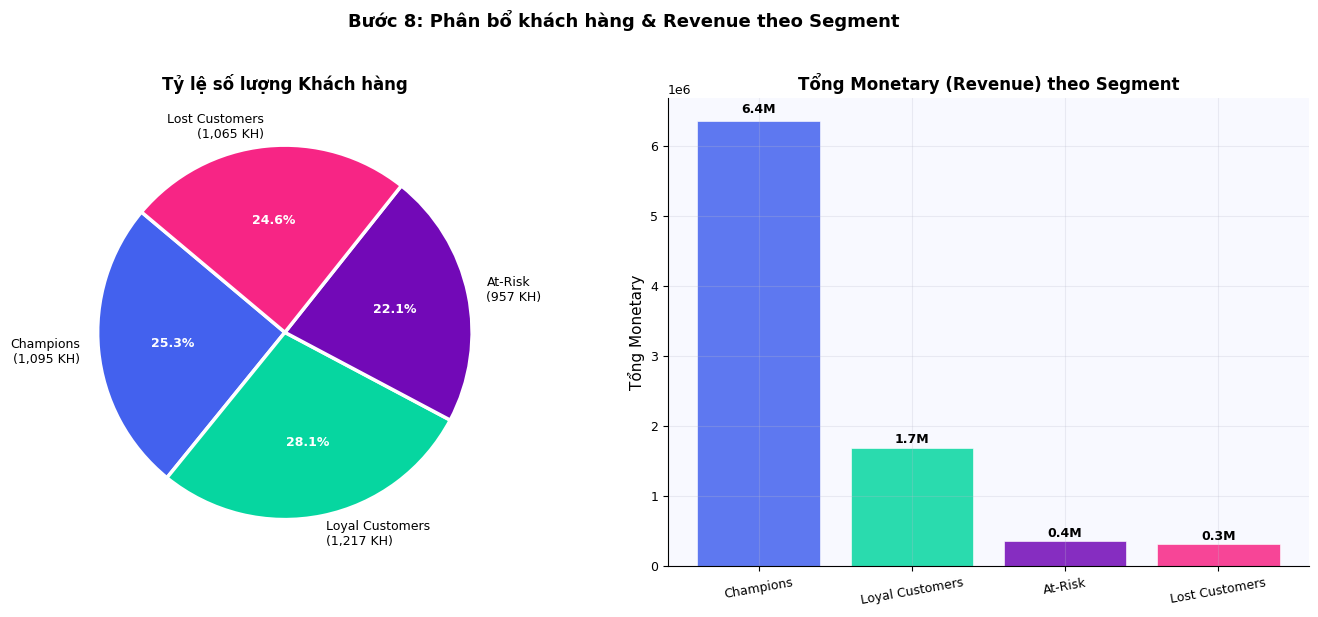

In [19]:
# ── Pie chart: Tỷ lệ phân khúc ───────────────────────────────────────────────
seg_counts = df['Segment'].value_counts()
seg_order  = ['Champions', 'Loyal Customers', 'At-Risk', 'Lost Customers']
seg_color_list = ['#4361EE', '#06D6A0', '#7209B7', '#F72585']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Bước 8: Phân bổ khách hàng & Revenue theo Segment',
             fontsize=13, fontweight='bold', y=1.02)

# Pie – số lượng KH
sizes = [seg_counts.get(s, 0) for s in seg_order]
wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels=[f'{s}\n({seg_counts.get(s,0):,} KH)' for s in seg_order],
    autopct='%1.1f%%', colors=seg_color_list,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=9))
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Tỷ lệ số lượng Khách hàng', fontweight='bold')

# Bar – tổng revenue
revenue = [df[df['Segment']==s]['Monetary'].sum() for s in seg_order]
bars = axes[1].bar(seg_order, revenue, color=seg_color_list, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('Tổng Monetary (Revenue) theo Segment', fontweight='bold')
axes[1].set_ylabel('Tổng Monetary')
axes[1].set_xticklabels(seg_order, rotation=10, fontsize=9)
for bar, val in zip(bars, revenue):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val/1e6:.1f}M', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


###  Chiến lược Marketing theo từng phân khúc

| Segment | Profile | Chiến lược ưu tiên |
|---|---|---|
| 🏆 **Champions** | Recency thấp, Frequency cao, Monetary cao | Reward loyalty, mời thử sản phẩm mới, VIP program, ambassador |
| ⭐ **Loyal Customers** | Mua đều đặn, chi tiêu trung bình | Upsell sang tier cao hơn, referral program, ưu đãi thành viên |
| ⚠️ **At-Risk** | Mới mua 1 lần gần đây, chi ít | Cross-sell thông minh, email nurturing, ưu đãi lần mua thứ 2 |
| 😴 **Lost Customers** | Lâu không mua, tần suất thấp | Win-back campaign, khảo sát lý do rời đi, ưu đãi sốc để kéo lại |


In [20]:
# ── Export kết quả ra file CSV ────────────────────────────────────────────────
output = df[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].copy()
output.to_csv('rfm_clustered_result.csv', index=False)

print(f"✅ Đã xuất file 'rfm_clustered_result.csv'")
print(f"   Tổng {len(output):,} khách hàng đã được phân cụm")
print()
print(output.groupby('Segment').agg(
    Count=('CustomerID','count'),
    Recency_mean=('Recency','mean'),
    Frequency_mean=('Frequency','mean'),
    Monetary_mean=('Monetary','mean'),
).round(1).to_string())


✅ Đã xuất file 'rfm_clustered_result.csv'
   Tổng 4,334 khách hàng đã được phân cụm

                 Count  Recency_mean  Frequency_mean  Monetary_mean
Segment                                                            
At-Risk            957          36.1             1.4          384.2
Champions         1095          14.2            10.6         5805.2
Lost Customers    1065         231.0             1.2          305.9
Loyal Customers   1217          86.9             3.5         1391.8
